In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [29]:
image=cv.imread('myimage.jpg')
img = cv.resize(image, (256, 256))
img=cv.cvtColor(img, cv.COLOR_RGB2GRAY)

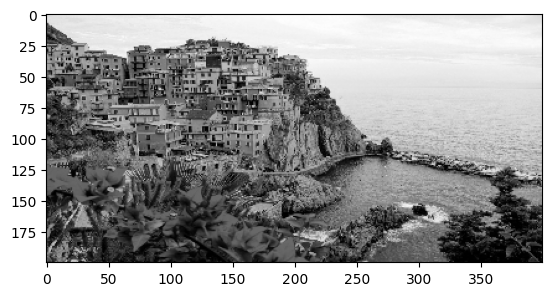

In [175]:
plt.imshow(img,cmap='gray')

In [25]:
import numpy as np

def isotropic(image, T, dt):
    img = image.copy()
    I, J = img.shape
    
    for t in range(T):
        # discrete Laplacian using numpy.roll
        north = np.roll(img, 1, axis=0)
        south = np.roll(img, -1, axis=0)
        west  = np.roll(img, 1, axis=1)
        east  = np.roll(img, -1, axis=1)
        laplacian = north + south + west + east - 4*img
        img = img + dt * laplacian

        # Neumann boundary condition (edges equal to neighbors)
        img[0, :]    = img[1, :]
        img[-1, :]   = img[-2, :]
        img[:, 0]    = img[:, 1]
        img[:, -1]   = img[:, -2]

    return img


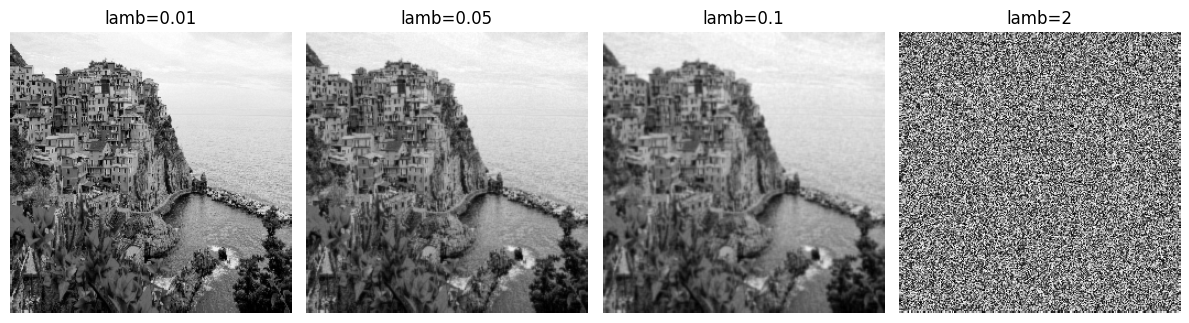

In [33]:
lambdaa=[0.01,0.05,0.1,2]
images_diff=[isotropic(img,5,lamb) for lamb in lambdaa]

titles=['lamb=0.01','lamb=0.05','lamb=0.1','lamb=2']
plt.figure(figsize=(12,10))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images_diff[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()